In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pickle

In [2]:
df=pd.read_csv(r'c:\Users\Nishant\OneDrive\Documents\employee\WA_Fn-UseC_-HR-Employee-Attrition.csv',index_col=0)

In [3]:
df.head(7)


,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,,,,,,,,,,,,,,,,,,,,,
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2
32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,...,3,80,0,8,2,2,7,7,3,6
59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,...,1,80,3,12,3,2,1,0,0,0


understanding data


In [4]:
df.columns

Index(['Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [5]:
df.shape

(1470, 34)

In [6]:
df.describe()

,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 41 to 34
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Attrition                 1470 non-null   object
 1   BusinessTravel            1470 non-null   object
 2   DailyRate                 1470 non-null   int64 
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                   1470

In [8]:
#target distribution
tt=df['Attrition'].value_counts()
print(tt)



Attrition
No     1233
Yes     237
Name: count, dtype: int64


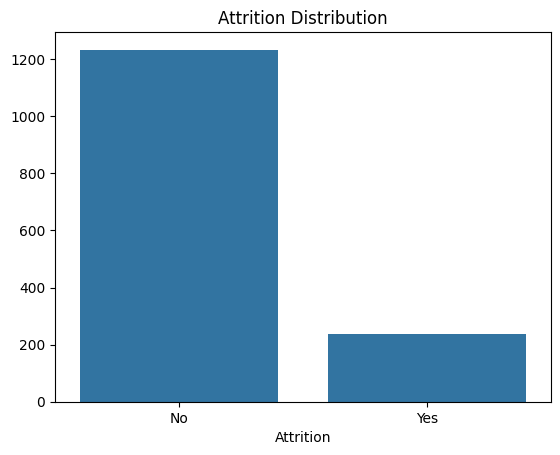

In [9]:
sns.barplot(x=tt.index, y=tt.values)
plt.title('Attrition Distribution')
plt.show()

cleaning of the dataset

In [10]:
#checking for the missing values 
df.isna().sum()

Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithC

In [11]:
#checking for the dublicate values
df.duplicated().sum()

np.int64(0)

EDA

<Axes: xlabel='Gender', ylabel='Count'>

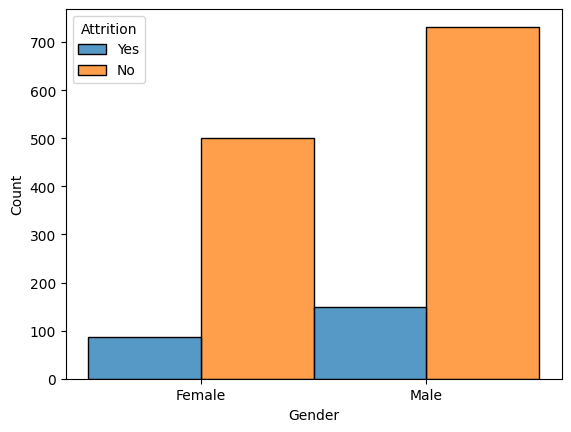

In [12]:
#PLOTING THE DISTRIBUTION GENDER VS ATTRITION
sns.histplot(data=df,x='Gender',hue='Attrition',multiple='dodge',stat='count')

In [13]:
c=pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100
print(c)

Attrition         No        Yes
OverTime                       
No         89.563567  10.436433
Yes        69.471154  30.528846


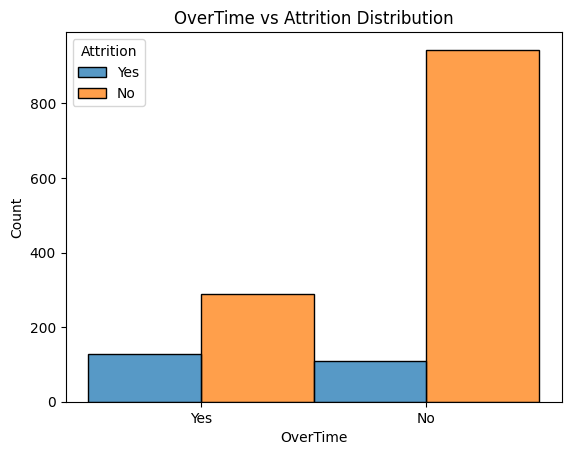

In [14]:
#ploting the distribution of over time vs attrition
sns.histplot(data=df,x='OverTime',hue='Attrition',multiple='dodge',stat='count')
plt.title('OverTime vs Attrition Distribution')
plt.show()

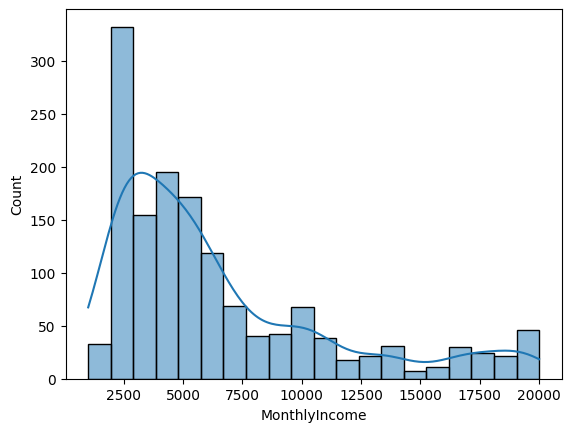

In [15]:
#monthly income distribution
sns.histplot(df['MonthlyIncome'], kde=True)
plt.show()

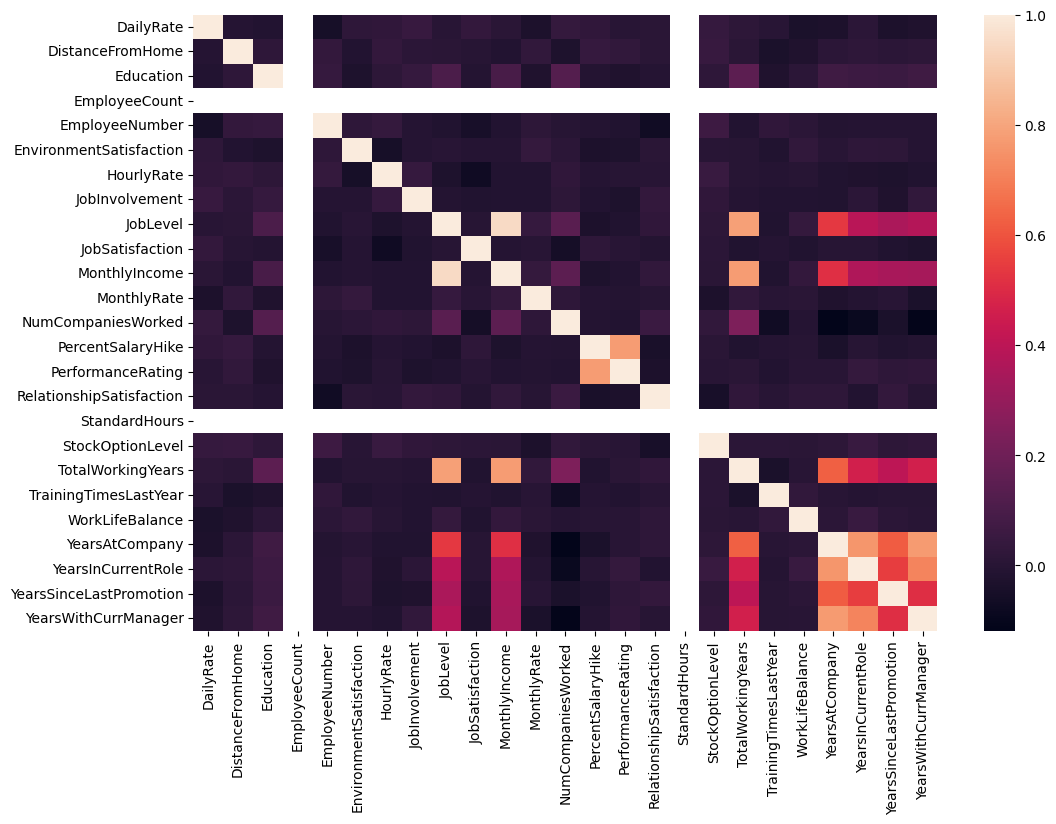

In [16]:
#correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr())
plt.show()

feature selection

In [17]:
#droping the columns which are not required for the model
df.drop([
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
], axis=1, inplace=True)

In [18]:
X=df.drop(['Attrition'], axis=1)
y=df['Attrition']

train & split


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
cat_cols = X.select_dtypes(
    include='object'
).columns

num_cols = X.select_dtypes(
    exclude='object'
).columns

print(cat_cols)

print(num_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')
Index(['DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [21]:
num_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='median'
            )
        )
    ]
)

In [22]:
cat_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent'
            )
        ),

        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            num_transformer,
            num_cols
        ),

        (
            'cat',
            cat_transformer,
            cat_cols
        )
    ]
)

In [24]:
lr_model = Pipeline([
    ('preprocessor',preprocessor),

    ('classifier',
     LogisticRegression(
         solver='liblinear',
         max_iter=5000
     ))
])

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(
    X_test
)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy: 0.8741496598639455


In [25]:
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.7687074829931972


In [26]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.8537414965986394


comparing the models

In [27]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.874150
2,Random Forest,0.853741
1,Decision Tree,0.768707


classification report


In [28]:
print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

          No       0.87      1.00      0.93       247
         Yes       0.92      0.23      0.37        47

    accuracy                           0.87       294
   macro avg       0.89      0.61      0.65       294
weighted avg       0.88      0.87      0.84       294



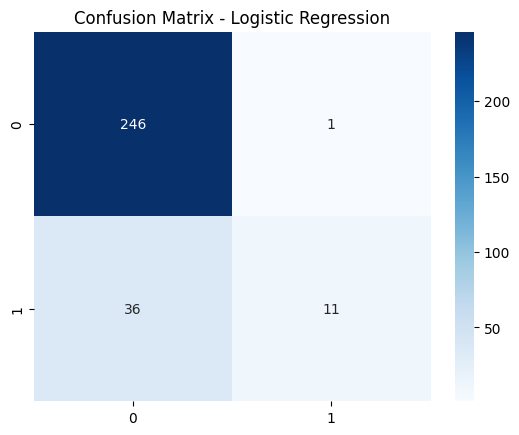

In [29]:
#confusion matrix for logistic regression
cm = confusion_matrix(
    y_test,
    lr_pred
)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [30]:
import pickle

pickle.dump(
    lr_model,
    open(
        "employee_attrition.pkl",
        "wb"
    )
)

In [32]:
import os
print(os.path.abspath("employee_attrition.pkl"))

C:\Users\Nishant\employee_attrition.pkl


In [33]:
print(X.columns.tolist())

['BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
